<a href="https://colab.research.google.com/github/Vyshnavi725/predictve-analysis/blob/houseprice-prediction/houseprice%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Sample Data ---
          SqFt  Bedrooms  Bathrooms    Location  YearBuilt          Price
0  2048.357077         4        3.0  CityCenter       2006  473971.515761
1  1730.867849         5        1.0     SuburbB       1998  393825.145247
2  2123.844269         2        1.0     SuburbB       1994  347858.909956
3  2561.514928         5        1.0     SuburbB       2015  458468.913195
4  1682.923313         4        4.0     SuburbB       1994  437638.794904

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SqFt       1000 non-null   float64
 1   Bedrooms   1000 non-null   int64  
 2   Bathrooms  1000 non-null   float64
 3   Location   1000 non-null   object 
 4   YearBuilt  1000 non-null   int64  
 5   Price      1000 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 47.0+ KB

--- Basic Statistics ---
   

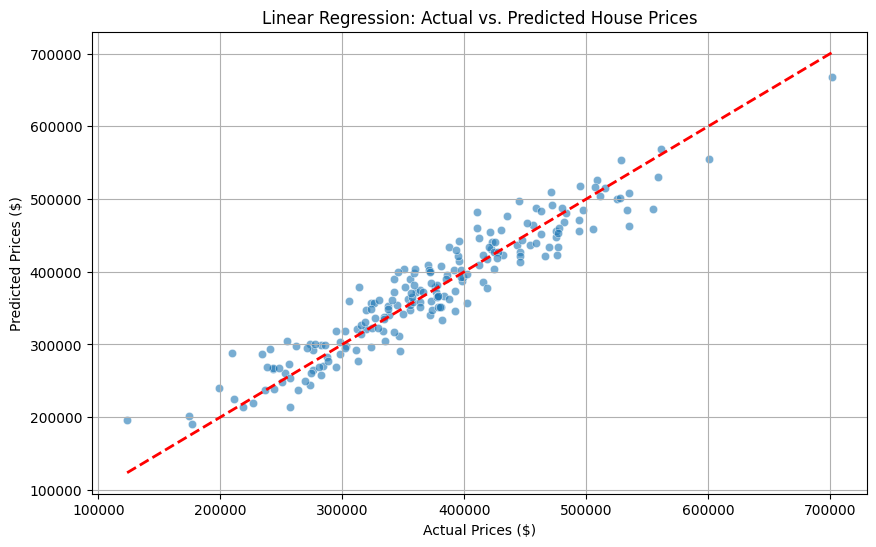


--- Random Forest Regressor Evaluation ---
Mean Absolute Error (MAE): $27,998.49
Mean Squared Error (MSE): $1,306,590,807.79
Root Mean Squared Error (RMSE): $36,146.80
R-squared (R²): 0.8368


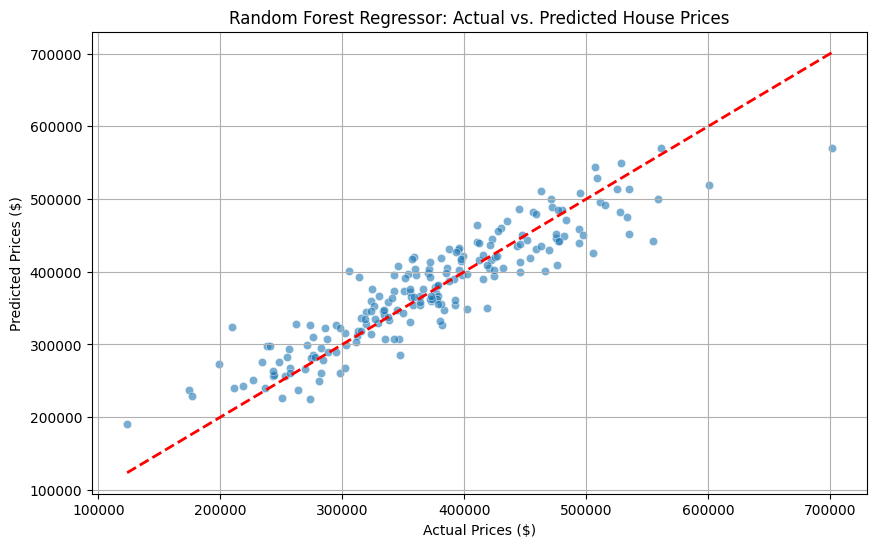


--- Making New Predictions ---

--- Predicted Prices using Linear Regression ---
House 1: $424,203.23
House 2: $256,735.65
House 3: $622,460.23

--- Predicted Prices using Random Forest Regressor ---
House 1: $425,873.62
House 2: $285,984.15
House 3: $579,085.64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
num_samples = 1000
data = {
    'SqFt': np.random.normal(1800, 500, num_samples),
    'Bedrooms': np.random.randint(2, 6, num_samples),
    'Bathrooms': np.random.uniform(1, 4, num_samples).round(),
    'Location': np.random.choice(['SuburbA', 'SuburbB', 'CityCenter', 'Rural'], num_samples),
    'YearBuilt': np.random.randint(1950, 2020, num_samples),
    'Price': 0 # Placeholder for now, will calculate
}
df = pd.DataFrame(data)
df['Price'] = (df['SqFt'] * 150 +
               df['Bedrooms'] * 20000 +
               df['Bathrooms'] * 15000 +
               (2025 - df['YearBuilt']) * -500 + # Older houses slightly cheaper
               np.where(df['Location'] == 'CityCenter', 50000,
                        np.where(df['Location'] == 'SuburbA', 20000,
                                 np.where(df['Location'] == 'SuburbB', 10000, 0))) +
               np.random.normal(0, 30000, num_samples))
df['Price'] = df['Price'].apply(lambda x: max(100000, x))
print("--- Sample Data ---")
print(df.head())
print("\n--- Data Info ---")
df.info()
print("\n--- Basic Statistics ---")
print(df.describe())
df['HouseAge'] = 2025 - df['YearBuilt'] # Assuming current year is 2025
numerical_features = ['SqFt', 'Bedrooms', 'Bathrooms', 'HouseAge'] # Added 'HouseAge'
categorical_features = ['Location']
all_features = numerical_features + categorical_features
X = df[all_features]
y = df['Price']
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # handle_unknown='ignore' is good for new categories in test data
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("\n--- Training Linear Regression Model ---")
model_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])
model_lr.fit(X_train, y_train)
print("\n--- Training Random Forest Regressor Model ---")
model_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
model_rf.fit(X_train, y_train)
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Mean Squared Error (MSE): ${mse:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R-squared (R²): {r2:.4f}")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
    plt.xlabel("Actual Prices ($)")
    plt.ylabel("Predicted Prices ($)")
    plt.title(f"{model_name}: Actual vs. Predicted House Prices")
    plt.grid(True)
    plt.show()
evaluate_model(model_lr, X_test, y_test, "Linear Regression")
evaluate_model(model_rf, X_test, y_test, "Random Forest Regressor")
print("\n--- Making New Predictions ---")
new_house_data = pd.DataFrame({
    'SqFt': [2100, 1500, 3000],
    'Bedrooms': [3, 2, 4],
    'Bathrooms': [2.5, 1.0, 3.0],
    'Location': ['SuburbA', 'Rural', 'CityCenter'],
    'YearBuilt': [2000, 1985, 2015]
})
new_house_data['HouseAge'] = 2025 - new_house_data['YearBuilt']
new_house_data_for_prediction = new_house_data[all_features]
predicted_prices_lr = model_lr.predict(new_house_data_for_prediction)
predicted_prices_rf = model_rf.predict(new_house_data_for_prediction)
print("\n--- Predicted Prices using Linear Regression ---")
for i, price in enumerate(predicted_prices_lr):
    print(f"House {i+1}: ${price:,.2f}")
print("\n--- Predicted Prices using Random Forest Regressor ---")
for i, price in enumerate(predicted_prices_rf):
    print(f"House {i+1}: ${price:,.2f}")